In [12]:
# data analysis
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt
import seaborn as sns
from pyampute.exploration.md_patterns import mdPatterns
from pyampute.exploration.mcar_statistical_tests import MCARTest
import missingno as msno


# preprocessing
import sklearn.utils.validation
import sys
from scipy import stats
from scipy.stats import shapiro, distributions, loguniform
from scipy.stats.mstats import winsorize
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import train_test_split, GridSearchCV, HalvingRandomSearchCV, HalvingGridSearchCV, TunedThresholdClassifierCV, FixedThresholdClassifier
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, PowerTransformer, QuantileTransformer, MinMaxScaler, KBinsDiscretizer, Binarizer, PolynomialFeatures, LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer, make_column_selector
from feature_engine.outliers import Winsorizer
# from imblearn.over_sampling import SMOTE, SMOTENC
from sklearn.pipeline import Pipeline
from sklearn import set_config

# Feature Selection
from sklearn.feature_selection import SelectFromModel

# Modeling
from sklearn.linear_model import RidgeClassifier, LogisticRegression, RidgeClassifierCV, LogisticRegressionCV, SGDClassifier, Perceptron, PassiveAggressiveClassifier
from sklearn.svm import LinearSVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.dummy import DummyClassifier
import joblib
from sklearn import tree 
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier, RandomForestClassifier, ExtraTreesClassifier, BaggingClassifier, VotingClassifier, StackingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier 

# Metrics
from sklearn.metrics import confusion_matrix, recall_score, precision_score, balanced_accuracy_score, ConfusionMatrixDisplay, classification_report, precision_recall_curve, PrecisionRecallDisplay, log_loss, brier_score_loss, roc_curve, roc_auc_score, RocCurveDisplay, det_curve, DetCurveDisplay, fbeta_score, average_precision_score, matthews_corrcoef

# Calibration
from sklearn.calibration import calibration_curve, CalibrationDisplay, CalibratedClassifierCV

# Inspection
from sklearn.inspection import PartialDependenceDisplay

from credit_risk_modeling import model_eval
import importlib
importlib.reload(model_eval)

2026-02-09 12:16:14.158 | INFO     | credit_risk_modeling.config:<module>:11 - PROJ_ROOT path is: C:\Users\billy\OneDrive\Documents\Finance_Projects\credit_risk_modeling


<module 'credit_risk_modeling.model_eval' from 'C:\\Users\\billy\\OneDrive\\Documents\\Finance_Projects\\credit_risk_modeling\\src\\credit_risk_modeling\\model_eval.py'>

## Imports

In [13]:
X_train = pd.read_csv(
    filepath_or_buffer = "../data/processed/X_train_tree.csv"
)
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22686 entries, 0 to 22685
Data columns (total 19 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   numeric__person_age                          22686 non-null  float64
 1   numeric__person_income                       22686 non-null  float64
 2   numeric__person_emp_length                   22686 non-null  float64
 3   numeric__loan_amnt                           22686 non-null  float64
 4   numeric__loan_int_rate                       22686 non-null  float64
 5   numeric__loan_percent_income                 22686 non-null  float64
 6   numeric__cb_person_default_on_file           22686 non-null  float64
 7   numeric__cb_person_cred_hist_length          22686 non-null  float64
 8   ordinal__loan_grade                          22686 non-null  float64
 9   categorical__person_home_ownership_MORTGAGE  22686 non-null  float64
 10

In [14]:
X_test = pd.read_csv(
    filepath_or_buffer = "../data/processed/X_test_tree.csv"
)
X_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2917 entries, 0 to 2916
Data columns (total 19 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   numeric__person_age                          2917 non-null   float64
 1   numeric__person_income                       2917 non-null   float64
 2   numeric__person_emp_length                   2917 non-null   float64
 3   numeric__loan_amnt                           2917 non-null   float64
 4   numeric__loan_int_rate                       2917 non-null   float64
 5   numeric__loan_percent_income                 2917 non-null   float64
 6   numeric__cb_person_default_on_file           2917 non-null   float64
 7   numeric__cb_person_cred_hist_length          2917 non-null   float64
 8   ordinal__loan_grade                          2917 non-null   float64
 9   categorical__person_home_ownership_MORTGAGE  2917 non-null   float64
 10  

In [15]:
y_train = pd.read_csv(
    filepath_or_buffer = "../data/interim/y_train.csv"
)
y_train = y_train.values.ravel()

In [16]:
y_test = pd.read_csv(
    filepath_or_buffer = "../data/interim/y_test.csv"
)
y_test.head(1)
y_test = y_test.values.ravel()

## Compare Models

Not accouting for feature selection (unless), class imbalance, or hyperparameter tuning

In [17]:
untuned_models = [
    DummyClassifier(strategy="most_frequent"),
    tree.DecisionTreeClassifier(
        random_state = 42,
    ), # no sampling 
    AdaBoostClassifier(
        random_state=42
    ), # default estimator is DecisionTreeClassifier, default no sampling
    XGBClassifier(
        reg_lambda=0,
        reg_alpha=0,
        random_state=42
    ), # default embedded l2 regularization, default includes no sampling (but sampling is possible for both samples and features - would be pasting + subspacing so replacement=None)
    LGBMClassifier(
    objective='binary',
    reg_alpha = 0,
    reg_lambda = 0,
    random_state=42
    ), # default embedded l2 regularization, default includes no sampling (but sampling is possible for both samples and features - would be pasting + subspacing so replacement=None)
    HistGradientBoostingClassifier(
        l2_regularization= 0,
        random_state=42
    ), # no regularization, default no subsampling but can be turned on
    GradientBoostingClassifier(
        subsample = 1.0,
        random_state=42
    ), # default no subsampling regularization but Pasting can be turned on
    RandomForestClassifier(
        n_jobs=-1,
        random_state=42
    ), # default Bagging, Subspacing
    ExtraTreesClassifier(
        n_jobs=-1,
        random_state=42
    ), # default all samples but Bagging can be turned on, Subspacing for features
    BaggingClassifier(estimator=tree.DecisionTreeClassifier(
        random_state=42), 
        n_estimators=50, 
        bootstrap=True, 
        max_samples=1.0,
        max_features=1.0, 
        random_state=42),
    #VotingClassifier(
    #    estimators= [('lgbm', LGBMClassifier(n_jobs=-1, random_state=42)), ('xgb', XGBClassifier(n_jobs=-1, random_state=42)), ('hgb', HistGradientBoostingClassifier(random_state=42)), ('rf', RandomForestClassifier(n_jobs=-1, random_state=42))],
    #    voting='soft',
    #    n_jobs=-1
    # ), # technically not tree based model
    #StackingClassifier(
    #    estimators= [('lgbm', LGBMClassifier(n_jobs=-1,random_state=42)), ('xgb', XGBClassifier(n_jobs=-1, random_state=42)), ('hgb', HistGradientBoostingClassifier(random_state=42)), ('rf', RandomForestClassifier(n_jobs=-1, random_state=42))],
    #    final_estimator= LGBMClassifier(random_state=42),
    #    n_jobs=-1
    # ), # technically not tree based model
    #StackingClassifier(
    #    estimators= [('lgbm', LGBMClassifier(n_jobs=-1,random_state=42)), ('xgb', XGBClassifier(n_jobs=-1, random_state=42)), ('hgb', HistGradientBoostingClassifier(random_state=42)), ('rf', RandomForestClassifier(n_jobs=-1, random_state=42))],
    #    final_estimator= StackingClassifier(
    #        estimators= [('lgbm', LGBMClassifier(n_jobs=-1,random_state=42)), ('xgb', XGBClassifier(n_jobs=-1, random_state=42)), ('hgb', HistGradientBoostingClassifier(random_state=42)), ('rf', RandomForestClassifier(n_jobs=-1, random_state=42))],
    #        final_estimator= LGBMClassifier(n_jobs=-1, random_state=42),
    #        n_jobs=-1
    #    ), # technically not tree based model
    #    n_jobs=-1
    #) # multiple layer
]

In [18]:
lgbm = LGBMClassifier(
    objective='binary',
    reg_alpha = 0,
    reg_lambda = 0,
    random_state=42
    ).fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 4962, number of negative: 17724
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001748 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1114
[LightGBM] [Info] Number of data points in the train set: 22686, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.218725 -> initscore=-1.273111
[LightGBM] [Info] Start training from score -1.273111


In [19]:
lgbm.predict_proba(X_test)[0, 1]

0.033392476101413375

In [20]:

untuned_model_performance, fitted_models = model_eval.comparing_models(untuned_models, X_train, y_train, X_test, y_test)

[LightGBM] [Info] Number of positive: 4962, number of negative: 17724
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000110 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1114
[LightGBM] [Info] Number of data points in the train set: 22686, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.218725 -> initscore=-1.273111
[LightGBM] [Info] Start training from score -1.273111


In [22]:
untuned_model_performance['untuned_model'] = 1

## Hyperparameter Tuning, Class Imbalance, Feature Selection

### LGBMClassifier

In [23]:
lgbm = LGBMClassifier(
    objective='binary',
    unbalance = True,
    random_state=42
    )

In [24]:
lgbm_param_dist = {
    "num_leaves": stats.randint(16, 256),
    "min_data_in_leaf": stats.randint(10, 500),
    "max_depth": stats.randint(3, 10),
    "learning_rate": stats.loguniform(0.01, 0.2),
    "n_estimators": stats.randint(200, 1000),
    "feature_fraction": stats.uniform(0.6, 0.4),
    "bagging_fraction": stats.uniform(0.6, 0.4),
    "bagging_freq": stats.randint(1, 6),
    "lambda_l1": stats.loguniform(1e-3, 1),
    "lambda_l2" :stats.loguniform(1e-3, 1),
}

In [25]:
lgbm_tuned = HalvingRandomSearchCV(
estimator = lgbm,
param_distributions=lgbm_param_dist,
scoring = 'roc_auc',
n_jobs=-1,
random_state=42)

### XGBClassifier

In [26]:
xgbm = XGBClassifier(
    objective='binary:logistic',
    unbalance = True,
    random_state=42
    )

In [27]:
xgbm_param_dist = {
    "max_depth": stats.randint(3, 10),
    "min_child_weight": stats.loguniform(1e-1, 1e2),
    "gamma": stats.loguniform(1e-3, 1),
    "reg_alpha": stats.loguniform(1e-3, 10),
    "reg_lambda": stats.loguniform(1e-3, 10),
    "subsample": stats.uniform(0.5, 0.5),
    "colsample_bytree": stats.uniform(0.5, 0.5),
    "learning_rate": stats.loguniform(0.01, 0.3),
    "n_estimators": stats.randint(200, 1000),
}

In [28]:
xgbm_tuned = HalvingRandomSearchCV(
estimator = xgbm,
param_distributions=xgbm_param_dist,
scoring = 'roc_auc',
n_jobs=-1,
random_state=42)

### HistGradientBoosting

In [29]:
hgb = HistGradientBoostingClassifier(
    random_state=42, 
    class_weight='balanced')

In [30]:
hgb_param_dist = {
    "max_depth": stats.randint(3, 10),
    "max_leaf_nodes": stats.randint(15, 255),
    "min_samples_leaf": stats.randint(10, 200),
    "learning_rate": stats.loguniform(0.01, 0.2),
    "max_iter": stats.randint(200, 1000),
    "l2_regularization": stats.loguniform(1e-3, 1),
    "max_bins": stats.randint(64, 255),
}

In [31]:
hgb_tuned = HalvingRandomSearchCV(
estimator = hgb,
param_distributions=hgb_param_dist,
scoring = 'roc_auc',
n_jobs=-1,
random_state=42)

### Random Forest

In [32]:
rf = RandomForestClassifier(
    n_jobs=-1, 
    random_state=42, 
    class_weight='balanced')

In [33]:
rf_param_dist = {
    "max_depth": stats.randint(3, 20),
    "min_samples_split": stats.randint(2, 20),
    "min_samples_leaf": stats.randint(1, 10),
    "n_estimators": stats.randint(200, 1000),
    "max_features": stats.uniform(0.4, 0.6),
    "bootstrap": [True, False],
    "max_leaf_nodes": stats.randint(10, 200),
}

In [34]:
rf_tuned = HalvingRandomSearchCV(
estimator = rf,
param_distributions=rf_param_dist,
scoring = 'roc_auc',
n_jobs=-1,
random_state=42)

In [35]:
model_eval.get_model_label(rf_tuned)

'HalvingRandomSearchCV (n_jobs=-1)'

### Manually tuning

In [36]:
manually_tuned_models = [
    lgbm_tuned,
    xgbm_tuned,
    hgb_tuned,
    rf_tuned
]

In [41]:
manual_tuned_model_performance

,model,roc_auc,pr_auc,log_loss,brier_score,matthews_corrcoef,untuned_model
1,XGBClassifier (n_jobs=None),0.947449,0.901233,0.190545,0.053387,0.801137,0
0,LGBMClassifier (n_jobs=None),0.946621,0.900078,0.231786,0.067373,0.744610,0
2,HistGradientBoostingClassifier,0.933578,0.879605,0.278324,0.082474,0.709295,0
3,RandomForestClassifier (n_jobs=-1),0.931615,0.877326,0.261318,0.072888,0.761148,0


In [37]:
manual_tuned_model_performance, fitted_models_manual = model_eval.comparing_manually_tuned_models(manually_tuned_models, X_train, y_train, X_test, y_test)

c:\Users\billy\anaconda3\envs\credit_risk_modeling\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [nan nan nan ... nan nan nan]
  warnings.warn(
c:\Users\billy\anaconda3\envs\credit_risk_modeling\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [nan nan nan ... 0.5 0.5 0.5]
  warnings.warn(
c:\Users\billy\anaconda3\envs\credit_risk_modeling\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [       nan        nan        nan ... 0.77449704 0.7831618  0.80942423]
  warnings.warn(
c:\Users\billy\anaconda3\envs\credit_risk_modeling\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [       nan        nan        nan ... 0.86830714 0.85975253 0.86081905]
  warnings.warn(
c:\Users\billy\anaconda3\envs\credit_risk_modeli

[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] feature_fraction is set=0.7417085308868863, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7417085308868863
[LightGBM] [Warning] lambda_l1 is set=0.002070315117862653, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.002070315117862653
[LightGBM] [Warning] lambda_l2 is set=0.004646050373911615, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.004646050373911615
[LightGBM] [Warning] bagging_fraction is set=0.9563422139932587, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9563422139932587
[LightGBM] [Warning] bagging_freq is set=2, subsample_freq=0 will be ignored. Current value: bagging_freq=2
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] feature_fraction is set=0.7417085308868863, colsamp

c:\Users\billy\anaconda3\envs\credit_risk_modeling\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [nan nan nan ... nan nan nan]
  warnings.warn(
c:\Users\billy\anaconda3\envs\credit_risk_modeling\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [       nan        nan        nan ... 0.56181818 0.74333333 0.54545455]
  warnings.warn(
c:\Users\billy\anaconda3\envs\credit_risk_modeling\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [       nan        nan        nan ... 0.79970473 0.79622325 0.79873957]
  warnings.warn(
c:\Users\billy\anaconda3\envs\credit_risk_modeling\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [       nan        nan        nan ... 0.87680222 0.86301152 0.87154408]
  warnings.warn(
c:\Use

In [38]:
manual_tuned_model_performance['untuned_model'] = 0

In [39]:
manual_tuned_model_performance = manual_tuned_model_performance.sort_values(
    ascending= False,
    by= 'roc_auc'
)

## Probability Calibration

In [42]:
untuned_model_performance

,model,roc_auc,pr_auc,log_loss,brier_score,matthews_corrcoef,untuned_model
3,XGBClassifier (n_jobs=None),0.944799,0.899640,0.197421,0.054818,0.801365,1
4,LGBMClassifier (n_jobs=None),0.944686,0.898316,0.193189,0.054168,0.793212,1
5,HistGradientBoostingClassifier,0.942786,0.894958,0.195382,0.054750,0.799962,1
6,GradientBoostingClassifier,0.926956,0.872853,0.229722,0.063494,0.786024,1
7,RandomForestClassifier (n_jobs=-1),0.925349,0.871640,0.231395,0.060780,0.785721,1
9,BaggingClassifier (n_jobs=None),0.918636,0.867107,0.359166,0.060780,0.789797,1
8,ExtraTreesClassifier (n_jobs=-1),0.907378,0.836747,0.308994,0.075181,0.740348,1
2,AdaBoostClassifier,0.888702,0.765447,0.495560,0.155357,0.623877,1
1,DecisionTreeClassifier,0.837249,0.601609,4.176467,0.115872,0.665673,1
0,DummyClassifier,0.500000,0.218718,7.883391,0.218718,0.000000,1


In [43]:
manual_tuned_model_performance

,model,roc_auc,pr_auc,log_loss,brier_score,matthews_corrcoef,untuned_model
1,XGBClassifier (n_jobs=None),0.947449,0.901233,0.190545,0.053387,0.801137,0
0,LGBMClassifier (n_jobs=None),0.946621,0.900078,0.231786,0.067373,0.744610,0
2,HistGradientBoostingClassifier,0.933578,0.879605,0.278324,0.082474,0.709295,0
3,RandomForestClassifier (n_jobs=-1),0.931615,0.877326,0.261318,0.072888,0.761148,0


In [47]:
model_performances = model_eval.combine_model_performance(
    internal_tuned_models_df = None,
    manual_tuned_models_df = manual_tuned_model_performance, 
    untuned_model_performance = untuned_model_performance
    )

In [49]:
model_performances

,model,roc_auc,pr_auc,log_loss,brier_score,matthews_corrcoef,untuned_model
1,XGBClassifier (n_jobs=None),0.947449,0.901233,0.190545,0.053387,0.801137,0
0,LGBMClassifier (n_jobs=None),0.946621,0.900078,0.231786,0.067373,0.744610,0
3,XGBClassifier (n_jobs=None),0.944799,0.899640,0.197421,0.054818,0.801365,1
4,LGBMClassifier (n_jobs=None),0.944686,0.898316,0.193189,0.054168,0.793212,1
5,HistGradientBoostingClassifier,0.942786,0.894958,0.195382,0.054750,0.799962,1
2,HistGradientBoostingClassifier,0.933578,0.879605,0.278324,0.082474,0.709295,0
3,RandomForestClassifier (n_jobs=-1),0.931615,0.877326,0.261318,0.072888,0.761148,0
6,GradientBoostingClassifier,0.926956,0.872853,0.229722,0.063494,0.786024,1
7,RandomForestClassifier (n_jobs=-1),0.925349,0.871640,0.231395,0.060780,0.785721,1
9,BaggingClassifier (n_jobs=None),0.918636,0.867107,0.359166,0.060780,0.789797,1


Log loss (sigmoid): 0.2005
Brier score (sigmoid): 0.0546
Log loss (isotonic): 0.1889
Brier score (isotonic): 0.0533


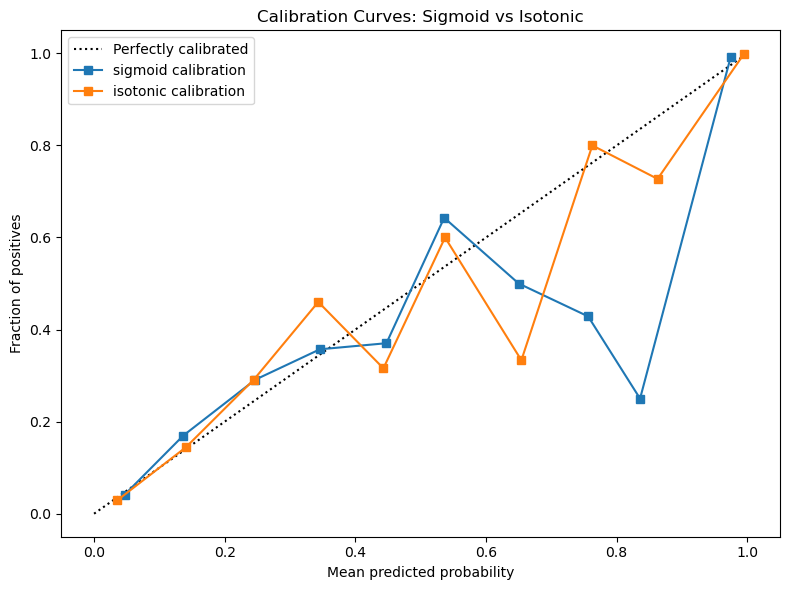

In [50]:
calibrated_models = model_eval.evaluate_calibration(model_performances, fitted_models, X_train, y_train, X_test, y_test)

In [51]:
calibrated_models

{'sigmoid': CalibratedClassifierCV(estimator=XGBClassifier(base_score=None, booster=None,
                                                callbacks=None,
                                                colsample_bylevel=None,
                                                colsample_bynode=None,
                                                colsample_bytree=None,
                                                device=None,
                                                early_stopping_rounds=None,
                                                enable_categorical=False,
                                                eval_metric=None,
                                                feature_types=None,
                                                feature_weights=None, gamma=None,
                                                grow_policy=None,
                                                importance_type=None,
                                                interaction_constrain

In [52]:
top_performing_calibrated_model = calibrated_models['isotonic']

## Decision Threshold Comparison

Classification Report (Base Estimator):
               precision    recall  f1-score   support

       False       0.93      1.00      0.96      2279
        True       0.98      0.72      0.83       638

    accuracy                           0.93      2917
   macro avg       0.95      0.86      0.89      2917
weighted avg       0.94      0.93      0.93      2917

Business Cost (Base Estimator): $1815500


c:\Users\billy\anaconda3\envs\credit_risk_modeling\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\billy\anaconda3\envs\credit_risk_modeling\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\billy\anaconda3\envs\credit_risk_modeling\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

Classification Report (Tuned Estimator):
               precision    recall  f1-score   support

       False       0.00      0.00      0.00      2279
        True       0.22      1.00      0.36       638

    accuracy                           0.22      2917
   macro avg       0.11      0.50      0.18      2917
weighted avg       0.05      0.22      0.08      2917

Business Cost (Tuned Estimator): $1139500


c:\Users\billy\anaconda3\envs\credit_risk_modeling\Lib\site-packages\sklearn\utils\_plotting.py:440: FutureWarning: y_pred was deprecated in 1.8 and will be removed in 1.10. Please use `y_score` instead.
  warnings.warn(


Classification Report (Chosen Threshold):
               precision    recall  f1-score   support

       False       0.98      0.64      0.78      2279
        True       0.43      0.96      0.59       638

    accuracy                           0.71      2917
   macro avg       0.71      0.80      0.68      2917
weighted avg       0.86      0.71      0.74      2917

Business Cost (Chosen Threshold): $677000


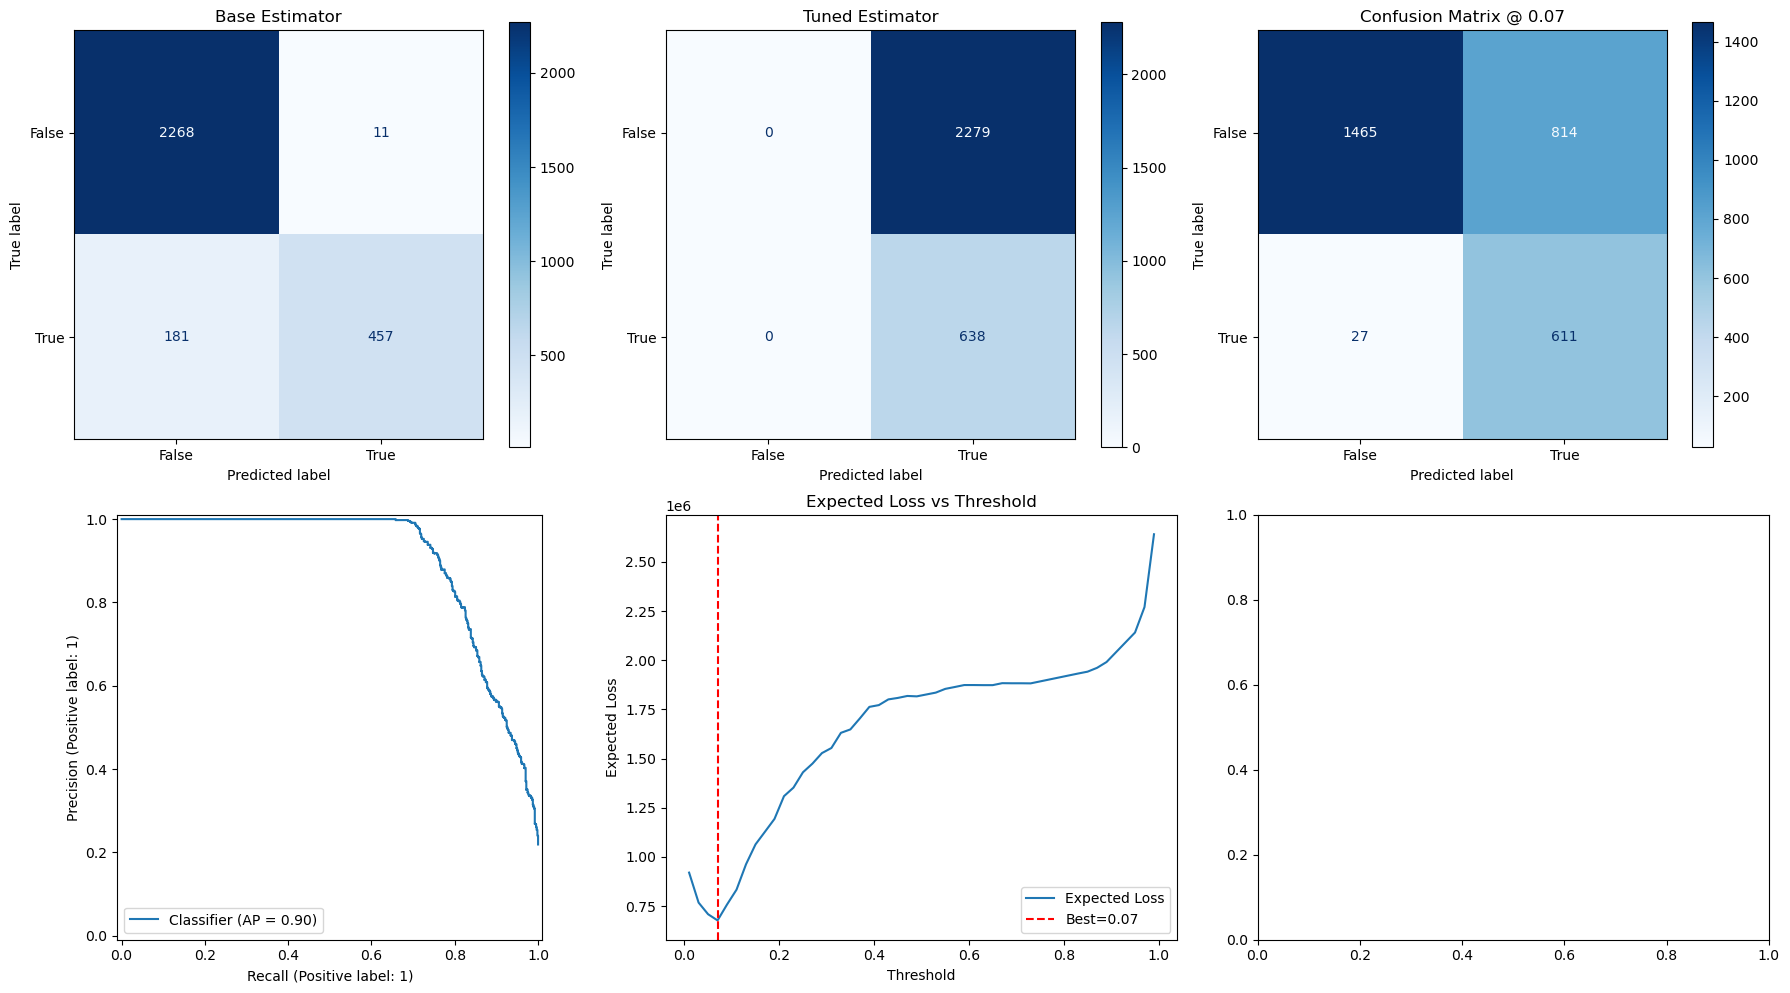

In [53]:
final_model_eval = model_eval.decision_threshold_comparisons(top_performing_calibrated_model, X_train, y_train, X_test, y_test)

In [54]:
best_tree_model = final_model_eval['chosen_estimator']

In [55]:
best_tree_model

,"estimator estimator: estimator instanceThe binary classifier, fitted or not, for which we want to optimizethe decision threshold used during `predict`.","CalibratedCla...c', n_jobs=-1)"
,"threshold threshold: {""auto""} or float, default=""auto""The decision threshold to use when converting posterior probability estimates(i.e. output of `predict_proba`) or decision scores (i.e. output of`decision_function`) into a class label. When `""auto""`, the threshold is setto 0.5 if `predict_proba` is used as `response_method`, otherwise it is set to0 (i.e. the default threshold for `decision_function`).",0.06999999999999999
,"pos_label pos_label: int, float, bool or str, default=NoneThe label of the positive class. Used to process the output of the`response_method` method. When `pos_label=None`, if `y_true` is in `{-1, 1}` or`{0, 1}`, `pos_label` is set to 1, otherwise an error will be raised.",None
,"response_method response_method: {""auto"", ""decision_function"", ""predict_proba""}, default=""auto""Methods by the classifier `estimator` corresponding to thedecision function for which we want to find a threshold. It can be:* if `""auto""`, it will try to invoke `""predict_proba""` or `""decision_function""` in that order.* otherwise, one of `""predict_proba""` or `""decision_function""`. If the method is not implemented by the classifier, it will raise an error.",'auto'
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None


In [56]:
joblib.dump(best_tree_model, "../models/best_tree_model.pkl")

['../models/best_tree_model.pkl']

In [57]:
# Check what the trained model expects
print(f"Model n_features_in_: {best_tree_model.n_features_in_}")
print(f"X_train_tree shape: {X_train.shape}")

# If they differ, we need to find where the extra features came from
if X_train.shape[1] != best_tree_model.n_features_in_:
    print(f"\n⚠️ MISMATCH: X_train has {X_train.shape[1]} features but model expects {best_tree_model.n_features_in_}")
    print("This suggests features were added during hyperparameter tuning or model training")

Model n_features_in_: 19
X_train_tree shape: (22686, 19)
